# 04 — Configuration 4 — Forecast horizon H = 1, 6, 12, 24, 168 h

**Question.** How do accuracy and stability evolve with the horizon?

**Hypotheses.** The error grows with the horizon up to the daily cycle; beyond it (168 h), the recent cloud information is lost and the forecast tends towards a conditional climatology. The comparison with persistence is made at the same horizon.

**Fixed parameters.** P, L and channel handling selected in configurations 1 to 3.

**Protocol** (identical for every configuration — module `patchtst_pv`, section 8):
1. training on Train (2019–2021), early stopping on Val (01–09/2022), **5 seeds**;
2. accuracy on **every hourly origin of the Test set** (10/2022–05/2023): RMSE, MAE, nRMSE = RMSE / mean, R², MBE;
3. **robustness**: standard deviation over the seeds and 5 % Gaussian noise on the exogenous channels (rejected if ΔRMSE > 15 %);
4. **stability**: 30-day rolling forecast without re-training, drift = RMSE(D24–30) / RMSE(D1–7) (target < 1.2);
5. **efficiency**: inference time for one sample (< 100 ms) and weight size (< 50 MB);
6. **decision score** of `projet.md` (raw and normalised) and Diebold-Mariano tests against persistence and the 7-day mean.

> Trainings are cached (`cache/<configuration>/`): deleting the corresponding folder re-runs the full
> training from this notebook.

In [1]:
# --- Environment shared by all notebooks ------------------------------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patchtst_pv as m                # core module of the study (fully commented)
import figure_style as fs         # visual style of the paper's figures
fs.apply()
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)
import analysis as an, flowchart as fc, json, dataclasses
from nb_config import configs_for

## 1. Flowchart of the configuration

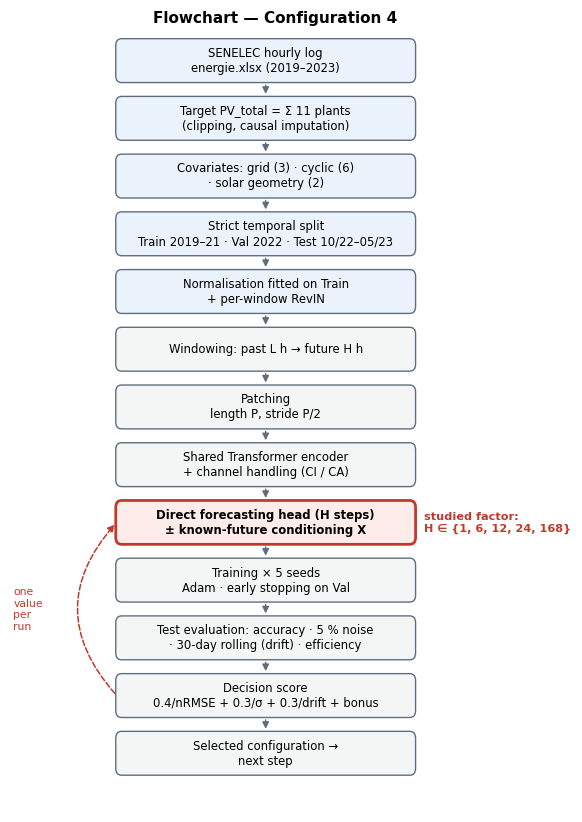

In [2]:
fc.draw(4, "Flowchart — Configuration 4", "flow_config4")

## 2. Configurations evaluated

In [3]:
ds = m.build_dataset()
configs = configs_for(4)
pd.DataFrame([dict(name=c.name(), P=c.P, L=c.L, H=c.H, channels=c.channel_mode, known_future=c.known_future,
                   physical_gate=c.physical_gate, n_patches=c.n_patches) for c in configs])

,name,P,L,H,channels,known_future,physical_gate,n_patches
0,PatchTST-CAX_P12_L168_H1,12,168,1,CA,True,False,27
1,PatchTST-CAX_P12_L168_H6,12,168,6,CA,True,False,27
2,PatchTST-CAX_P12_L168_H12,12,168,12,CA,True,False,27
3,PatchTST-CAX_P12_L168_H24,12,168,24,CA,True,False,27
4,PatchTST-CAX_P12_L168_H168,12,168,168,CA,True,False,27


## 3. Training and evaluation (5 seeds each)

In [4]:
results = [m.evaluate_configuration(c, ds) for c in configs]   # reads the cache if it exists
detail = pd.DataFrame([dict(configuration=r["name"], **{k: g[k] for k in
         ["seed", "epochs", "duration_s", "RMSE", "MAE", "nRMSE", "R2", "noise_degradation", "drift_7d", "drift_D30_D1"]})
         for r in results for g in r["per_seed"]])
detail

,configuration,seed,epochs,duration_s,RMSE,MAE,nRMSE,R2,noise_degradation,drift_7d,drift_D30_D1
0,PatchTST-CAX_P12_L168_H1,0,19,3902.7933,4.3481,2.9006,0.0982,0.9939,0.0019,0.5414,0.6541
1,PatchTST-CAX_P12_L168_H1,1,20,668.6840,4.4972,2.9607,0.1016,0.9935,0.0055,0.5414,0.7146
2,PatchTST-CAX_P12_L168_H1,2,15,499.8124,5.1848,3.5265,0.1171,0.9914,0.0010,0.6403,0.7653
3,PatchTST-CAX_P12_L168_H1,3,11,371.3378,6.1248,4.2937,0.1383,0.9880,0.0022,0.5894,0.8838
4,PatchTST-CAX_P12_L168_H1,4,23,774.1646,4.4976,3.2685,0.1016,0.9935,0.0044,0.5915,0.7483
5,PatchTST-CAX_P12_L168_H6,0,22,752.5926,7.5286,4.4202,0.1699,0.9818,0.0049,0.5142,0.9863
6,PatchTST-CAX_P12_L168_H6,1,21,729.4079,7.6890,4.4591,0.1735,0.9810,0.0039,0.5347,1.1254
7,PatchTST-CAX_P12_L168_H6,2,16,554.5746,7.6661,4.4654,0.1730,0.9811,0.0043,0.5462,0.9723
8,PatchTST-CAX_P12_L168_H6,3,13,433.7638,8.0239,4.8692,0.1811,0.9793,0.0048,0.5840,1.0248
9,PatchTST-CAX_P12_L168_H6,4,16,538.6127,7.7957,4.6027,0.1759,0.9805,0.0041,0.5649,0.9019


## 4. Comparison table of the metrics (mean over 5 seeds) and naive baselines

In [5]:
table = m.comparison_table(results)
_, true0, orig0 = an.load_predictions(results[0]["name"])
refs = an.baseline_rows(ds, orig0, true0, configs[0].H) if len({c.H for c in configs}) == 1 else None
columns = ["configuration", "RMSE", "RMSE_std", "MAE", "nRMSE", "nRMSE_day", "R2", "MBE", "noise_degradation",
           "drift_D30_D1", "drift_7d", "inference_ms", "size_MB", "n_parameters", "score", "normalised_score", "rejected_noise"]
shown = pd.concat([table[columns], refs], ignore_index=True) if refs is not None else table[columns]
m.TABLES_DIR.mkdir(exist_ok=True)
shown.to_csv(m.TABLES_DIR / "table_config4.csv", index=False)
shown.round(4)

,configuration,RMSE,RMSE_std,MAE,nRMSE,nRMSE_day,R2,MBE,noise_degradation,drift_D30_D1,drift_7d,inference_ms,size_MB,n_parameters,score,normalised_score,rejected_noise
0,PatchTST-CAX_P12_L168_H1,4.9305,0.7425,3.3900,0.1114,0.1128,0.9921,1.2265,0.0030,0.7532,0.5808,2.8717,0.5748,146858,4.7125,0.5000,False
1,PatchTST-CAX_P12_L168_H6,7.7406,0.1847,4.5633,0.1747,0.1830,0.9808,0.2435,0.0044,1.0021,0.5488,2.6767,0.6078,155503,4.6610,0.5688,False
2,PatchTST-CAX_P12_L168_H12,8.6091,0.0554,5.0398,0.1942,0.2031,0.9762,0.0719,0.0052,0.9113,0.5761,2.6194,0.6473,165877,8.1922,0.5713,False
3,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,5.2086,0.2037,0.2146,0.9739,-0.0050,0.0044,0.5752,0.5839,2.9255,0.7265,186625,5.7561,0.5267,False
4,PatchTST-CAX_P12_L168_H168,11.3349,0.0957,6.7918,0.2562,0.2713,0.9587,-0.4605,0.0040,0.5823,0.5985,2.9782,1.6762,435601,5.3970,0.3824,False


*Reading the columns.* `RMSE_std`: standard deviation over the 5 seeds (robustness). `nRMSE_day`: nRMSE restricted to
daytime hours. `noise_degradation`: relative RMSE increase under 5 % noise on the exogenous channels. `drift_D30_D1`: raw
ratio of `projet.md` (sensitive to the cloudiness of two isolated days); `drift_7d`: smoothed ratio used in the score.
`score`: raw formula of `projet.md`; `normalised_score`: each criterion mapped to [0, 1] across the compared variants.

In [6]:
dm = an.dm_tests(ds, results)
dm.round(4)

,configuration,reference,skill_score,DM,p_value
0,PatchTST-CAX_P12_L168_H1,persistence,0.5664,-15.3109,0.0000
1,PatchTST-CAX_P12_L168_H1,7-day mean,0.5836,-17.1403,0.0000
2,PatchTST-CAX_P12_L168_H6,persistence,0.2591,-4.8205,0.0000
3,PatchTST-CAX_P12_L168_H6,7-day mean,0.2885,-5.2440,0.0000
4,PatchTST-CAX_P12_L168_H12,persistence,0.1726,-3.6661,0.0002
5,PatchTST-CAX_P12_L168_H12,7-day mean,0.2054,-4.4607,0.0000
6,PatchTST-CAX_P12_L168_H24,persistence,0.1314,-2.9661,0.0030
7,PatchTST-CAX_P12_L168_H24,7-day mean,0.1659,-3.0762,0.0021
8,PatchTST-CAX_P12_L168_H168,persistence,0.1762,-2.5188,0.0118
9,PatchTST-CAX_P12_L168_H168,7-day mean,0.0499,-0.6551,0.5125


## 5. Seed rosary and 30-day stability

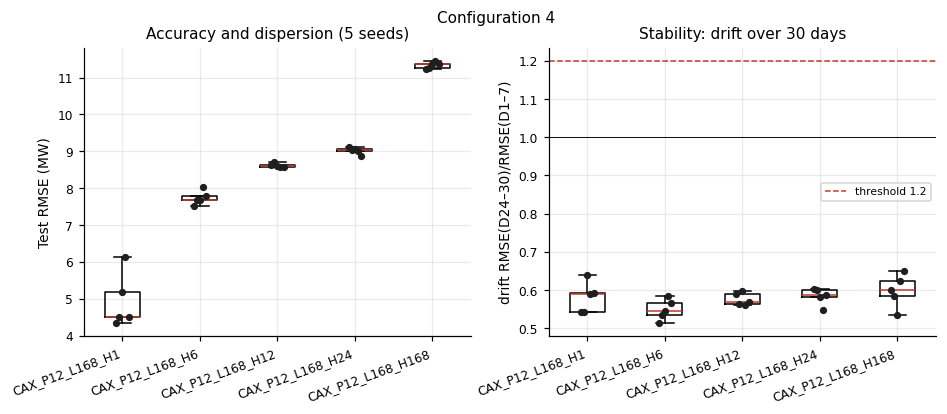

In [7]:
an.fig_rosary(results, ds, "fig_config4_rosary", "Configuration 4")

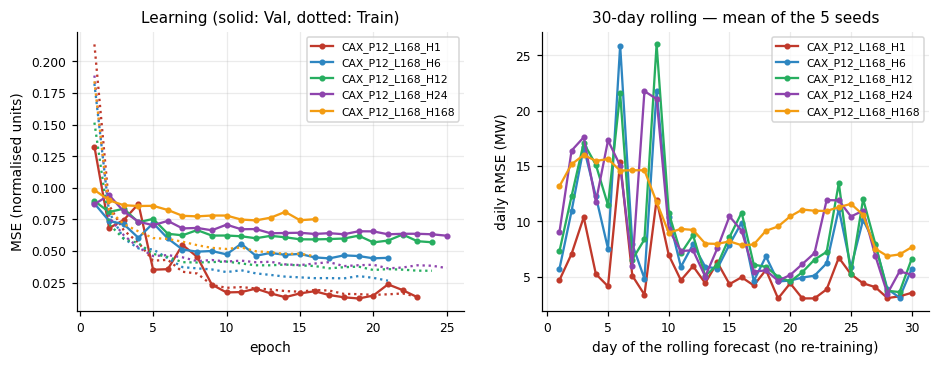

In [8]:
an.fig_learning_and_drift(results, "fig_config4_learning_drift")

## 6. Observed vs predicted series — best model of the configuration

Selected configuration: PatchTST-CAX_P12_L168_H12


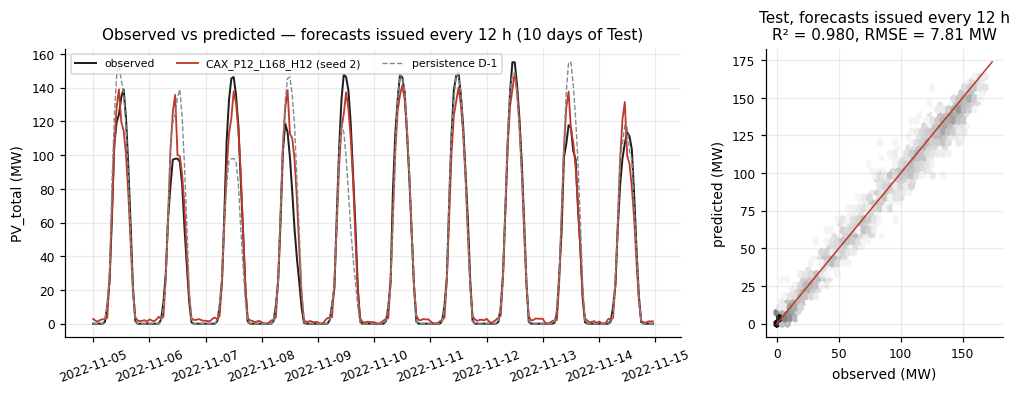

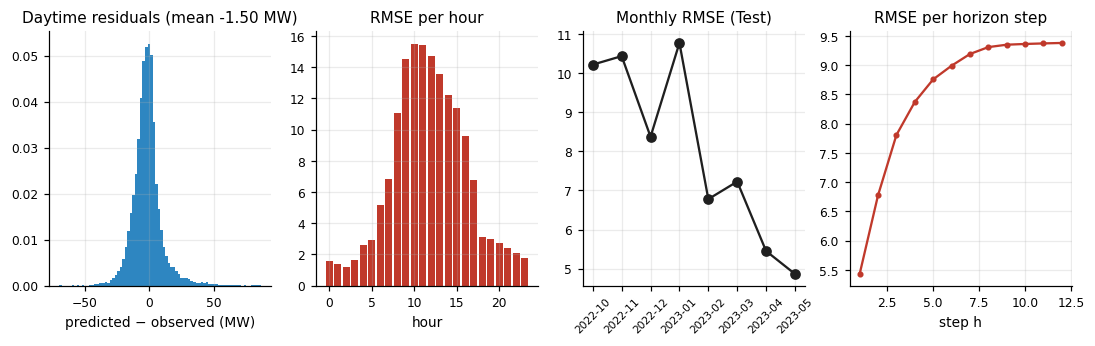

In [9]:
selected = an.selected_at("config4_horizon")
print("Selected configuration:", selected)
res_selected = [r for r in results if r["name"] == selected][0]
an.fig_observed_vs_predicted(res_selected, ds, "fig_config4_observed_predicted")
an.fig_residuals(res_selected, ds, "fig_config4_residuals")

### Conclusion of configuration 4

**Best score: `PatchTST-CAX_P12_L168_H12`.** Here the score compares different *tasks*: the 1 h error is mechanically lower than the 24 h error, so the horizon is not chosen by the score. The final model (notebook 05) is evaluated at the operational day-ahead horizon (24 h); this configuration describes how accuracy and stability evolve with the horizon, and the relevant comparison is the gain over persistence **at the same horizon**.

- `PatchTST-CAX_P12_L168_H1`: RMSE = 4.93 ± 0.74 MW, nRMSE = 0.111, gain vs persistence = +52.5 %, degradation under noise = +0.3 %, 7-day drift = 0.58, inference = 2.9 ms, 146,858 parameters.
- `PatchTST-CAX_P12_L168_H6`: RMSE = 7.74 ± 0.18 MW, nRMSE = 0.175, gain vs persistence = +25.4 %, degradation under noise = +0.4 %, 7-day drift = 0.55, inference = 2.7 ms, 155,503 parameters.
- `PatchTST-CAX_P12_L168_H12`: RMSE = 8.61 ± 0.06 MW, nRMSE = 0.194, gain vs persistence = +17.1 %, degradation under noise = +0.5 %, 7-day drift = 0.58, inference = 2.6 ms, 165,877 parameters.
- `PatchTST-CAX_P12_L168_H24`: RMSE = 9.02 ± 0.10 MW, nRMSE = 0.204, gain vs persistence = +13.2 %, degradation under noise = +0.4 %, 7-day drift = 0.58, inference = 2.9 ms, 186,625 parameters.
- `PatchTST-CAX_P12_L168_H168`: RMSE = 11.33 ± 0.10 MW, nRMSE = 0.256, gain vs persistence = +17.9 %, degradation under noise = +0.4 %, 7-day drift = 0.60, inference = 3.0 ms, 435,601 parameters.

- RMSE gap between the best and the worst variant: 6.40 MW (129.9 %).
- All variants meet the robustness criterion (degradation < 15 %): yes; all meet the drift target < 1.2: yes; all meet the efficiency targets (< 100 ms, < 50 MB): yes.